In [10]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\vashi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Step 1.1 — Dataset load

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(
    "../data/raw/financial_fraud_detection_dataset.csv"
)

df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


Step 1.2 — Dataset size

In [13]:
df.shape

(5000, 14)

Step 1.3 — Columns

In [14]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword',
       'Fraudulent'],
      dtype='str')

Step 1.4 — First five rows


In [15]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [16]:
df.tail()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
4995,T104995,CUST3702,01-08-2023 21:20,182.15,Electronics,Debit Card,Mobile,Kolkata,0,13,277.99,840,No,0
4996,T104996,CUST6007,14-01-2024 16:42,10.17,Fashion,Credit Card,Desktop,Chennai,0,128,477.24,441,No,0
4997,T104997,CUST6812,09-01-2023 22:14,31.78,Grocery,Debit Card,Mobile,Kolkata,1,76,442.62,1474,No,1
4998,T104998,CUST9120,18-08-2023 17:15,135.31,Utilities,Debit Card,Mobile,Bengaluru,0,13,73.33,246,No,0
4999,T104999,CUST1080,07-09-2023 21:20,72.77,Entertainment,UPI,Mobile,Bengaluru,0,146,30.23,699,No,0


In [17]:
df.sample(5, random_state=42)

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
1501,T101501,CUST7613,06-02-2023 03:10,52.19,Travel,UPI,Desktop,Bengaluru,1,154,157.70,1237,No,1
2586,T102586,CUST4507,16-10-2023 16:45,5.96,Grocery,UPI,Mobile,Hyderabad,0,135,431.73,232,No,0
2653,T102653,CUST8399,23-04-2023 18:19,4.30,Electronics,UPI,Desktop,Chennai,0,136,265.98,869,No,0
1055,T101055,CUST1793,29-04-2023 11:56,34.55,Grocery,Credit Card,Desktop,Delhi,0,6,304.56,791,No,0
705,T100705,CUST7605,26-05-2023 15:10,368.10,Health,PayPal,POS,Pune,1,182,328.05,1123,No,0


Step 1.5 — Data types

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   str    
 1   Customer_ID            5000 non-null   str    
 2   Transaction_Date       5000 non-null   str    
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   str    
 5   Payment_Method         5000 non-null   str    
 6   Device_Type            5000 non-null   str    
 7   Location               5000 non-null   str    
 8   Is_International       5000 non-null   int64  
 9   Previous_Transactions  5000 non-null   int64  
 10  Average_Spend          5000 non-null   float64
 11  Account_Age_Days       5000 non-null   int64  
 12  Suspicious_Keyword     5000 non-null   str    
 13  Fraudulent             5000 non-null   int64  
dtypes: float64(2), int64(4), str(8)
memory usage: 547.0 KB


Step 1.6 — Missing values

In [19]:
df.isnull().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

Step 1.7 — Duplicate rows

In [20]:
df.duplicated().sum()

np.int64(0)

Step 1.8 — Target distribution

In [21]:
df["Fraudulent"].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

In [22]:
df["Fraudulent"].value_counts(normalize=True) * 100

Fraudulent
0    90.36
1     9.64
Name: proportion, dtype: float64

Step 1.9 — Fraud distribution visualization

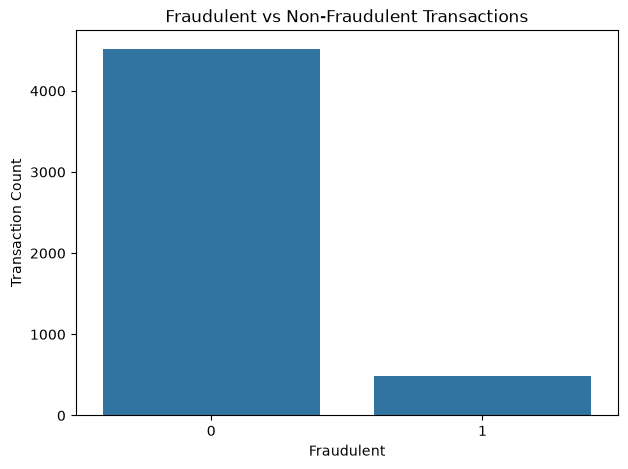

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Fraudulent")

plt.title("Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Fraudulent")
plt.ylabel("Transaction Count")

plt.show()

Step 1.10 — Transaction amount

In [24]:
df["Transaction_Amount"].describe()

count    5000.000000
mean       79.180664
std        78.964045
min         0.000000
25%        22.365000
50%        55.455000
75%       110.297500
max       653.800000
Name: Transaction_Amount, dtype: float64

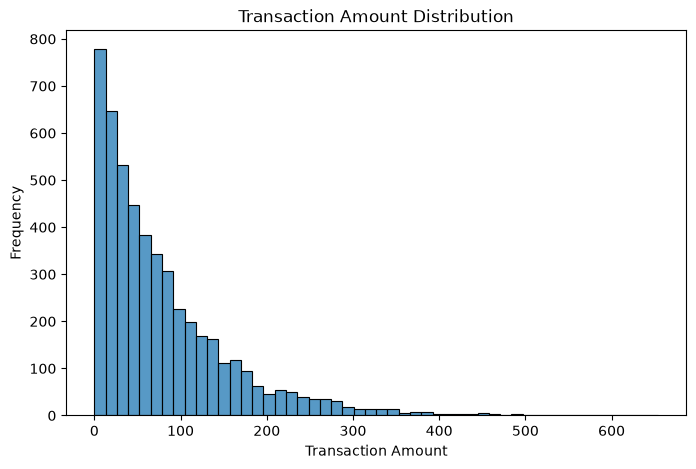

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Transaction_Amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

Step 1.11 — Fraud vs transaction amount

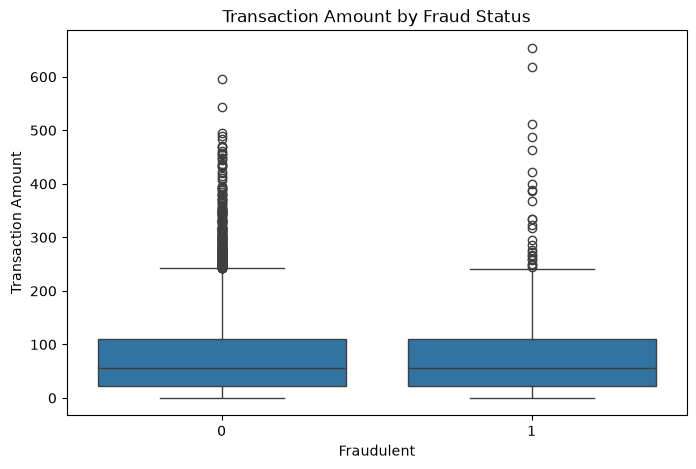

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Fraudulent",
    y="Transaction_Amount"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraudulent")
plt.ylabel("Transaction Amount")

plt.show()

Step 1.12 — Important numerical features

In [27]:
numeric_columns = [
    "Transaction_Amount",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days"
]

df[numeric_columns].describe()

,Transaction_Amount,Previous_Transactions,Average_Spend,Account_Age_Days
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,79.180664,99.414000,258.377132,1011.158200
std,78.964045,57.022968,140.230639,568.633834
min,0.000000,1.000000,10.010000,30.000000
25%,22.365000,50.000000,138.772500,530.000000
50%,55.455000,100.000000,261.810000,1012.500000
75%,110.297500,148.000000,378.525000,1496.000000
max,653.800000,199.000000,499.990000,1999.000000


Step 1.13 — Fraud by categorical features

In [28]:
pd.crosstab(
    df["Merchant_Category"],
    df["Fraudulent"],
    normalize="index"
) * 100

Fraudulent,0,1
Merchant_Category,,
Electronics,92.461538,7.538462
Entertainment,88.571429,11.428571
Fashion,89.802632,10.197368
Food,89.181287,10.818713
Grocery,90.779014,9.220986
Health,89.933993,10.066007
Travel,90.651085,9.348915
Utilities,91.582492,8.417508


In [29]:
pd.crosstab(
    df["Payment_Method"],
    df["Fraudulent"],
    normalize="index"
) * 100

Fraudulent,0,1
Payment_Method,,
Credit Card,90.123457,9.876543
Debit Card,89.781746,10.218254
NetBanking,91.803279,8.196721
PayPal,90.410959,9.589041
UPI,89.594173,10.405827


In [30]:
pd.crosstab(
    df["Location"],
    df["Fraudulent"],
    normalize="index"
) * 100

Fraudulent,0,1
Location,,
Bengaluru,89.650146,10.349854
Chennai,89.465649,10.534351
Delhi,91.424802,8.575198
Hyderabad,91.172414,8.827586
Kolkata,89.761571,10.238429
Mumbai,89.473684,10.526316
Pune,91.412742,8.587258


Step 1.14 — International transactions

In [31]:
pd.crosstab(
    df["Is_International"],
    df["Fraudulent"],
    normalize="index"
) * 100

Fraudulent,0,1
Is_International,,
0,93.002852,6.997148
1,63.038549,36.961451


Step 1.15 — Suspicious keyword

In [32]:
pd.crosstab(
    df["Suspicious_Keyword"],
    df["Fraudulent"],
    normalize="index"
) * 100

Fraudulent,0,1
Suspicious_Keyword,,
No,92.426160,7.573840
Yes,52.692308,47.307692


Step 1.16 — Correlation

In [33]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation["Fraudulent"].sort_values()

Previous_Transactions   -0.014649
Average_Spend            0.001114
Account_Age_Days         0.008563
Transaction_Amount       0.011637
Is_International         0.287913
Fraudulent               1.000000
Name: Fraudulent, dtype: float64

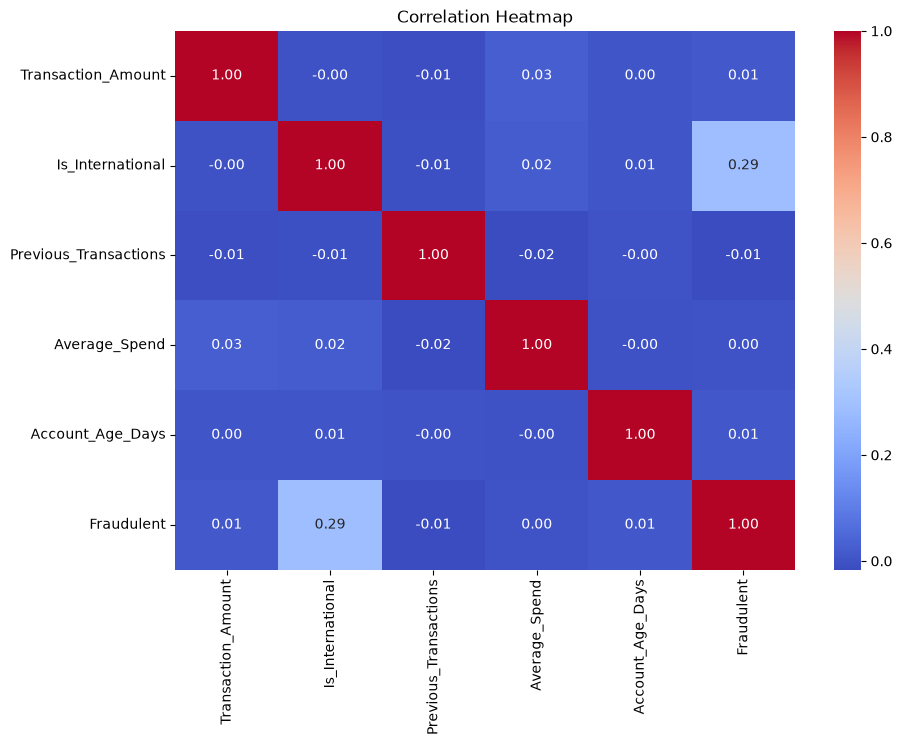

In [34]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()